## 1. Imports and Libraries

In [31]:
import kagglehub
import marimo as mo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Download latest version
path = kagglehub.dataset_download("nicolsvrancovich/buenos-aires-half-marathon-21k-results-20222025")

print("Path to dataset files:", path)

Path to dataset files: /home/srodriguez/.cache/kagglehub/datasets/nicolsvrancovich/buenos-aires-half-marathon-21k-results-20222025/versions/4


In [13]:
df = pd.read_csv(f"{path}/21k_Buenos_Aires_results_2022-2025.csv")

In [18]:
df.sort_values(by='chip_time_hours').columns

Index(['edition', 'position', 'bib_number', 'name', 'gender', 'age_group',
       'gun_time', 'chip_time', 'chip_time_hours'],
      dtype='str')

In [19]:
df.head(5)

,edition,position,bib_number,name,gender,age_group,gun_time,chip_time,chip_time_hours
0,2022,1,6,Dinkalem Ayele Adane,M,18-29,01:00:26,01:00:29,1.0081
1,2022,2,3,Gerba Beyata Dibaba,M,18-29,01:00:26,01:00:29,1.0081
2,2022,3,2,Felix Kibitok,M,30-34,01:00:30,01:00:32,1.0089
3,2022,4,1,Bedan Karoki,M,30-34,01:00:53,01:00:55,1.0153
4,2022,5,20,Christian Salvador Vasconez,M,30-34,01:01:56,01:01:59,1.0331


In [20]:
df.groupby("age_group")["chip_time_hours"].mean().sort_values()

age_group
30-34    1.991927
35-39    2.006725
18-29    2.009382
1-17     2.033400
40-44    2.048966
45-49    2.106146
50-54    2.158489
55-59    2.207217
60-64    2.285214
65-69    2.368939
70-74    2.428922
70+      2.552251
75-79    2.644820
80+      2.939122
Name: chip_time_hours, dtype: float64

In [26]:
df.groupby(["age_group", "gender"])["chip_time_hours"].agg(["mean", "median", "count"])

mean   median  count
age_group gender                          
1-17      F       2.151940  2.06080      5
          M       1.998535  1.97190     17
18-29     F       2.149759  2.14170   4698
          M       1.898150  1.89190   5929
30-34     F       2.148067  2.13545   5256
          M       1.871947  1.86205   6840
35-39     F       2.173026  2.16250   5793
          M       1.893106  1.88140   8479
40-44     F       2.192225  2.17580   6661
          M       1.936531  1.92580   8487
45-49     F       2.239538  2.22280   6350
          M       1.996738  1.98530   7742
50-54     F       2.288394  2.26170   4460
          M       2.061506  2.04310   5974
55-59     F       2.348881  2.33390   2128
          M       2.123709  2.10530   3610
60-64     F       2.443945  2.40610    800
          M       2.214667  2.19025   1800
65-69     F       2.490863  2.45360    235
          M       2.330168  2.29610    739
70+       F       2.877632  2.84000     19
          M       2.503572  2.46440    127
70-74     F       2.599345  2.61765     44
          M       2.375360  2.32750    140
75-79     F       3.093933  3.08085      6
          M       2.573908  2.47445     38
80+       F       2.886080  2.76780      5
          M       3.005425  2.90445      4

In [51]:
options = df["age_group"].dropna().astype(str).tolist()

In [58]:
age = mo.ui.dropdown(
    options=options,
    value=options[0],
    label="Select age group"
)

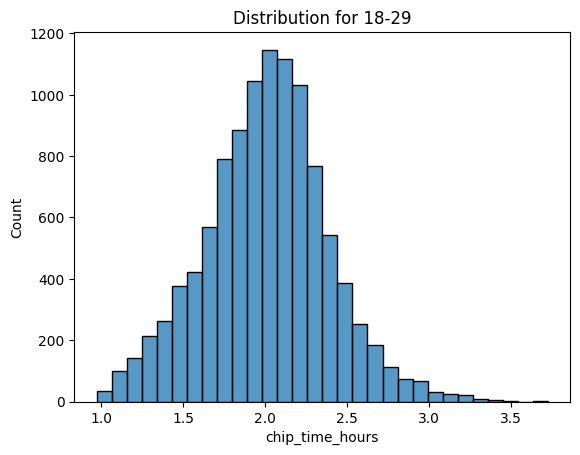

In [59]:
filtered = df[df["age_group"] == age.value]

plt.figure()
sns.histplot(filtered["chip_time_hours"], bins=30)
plt.title(f"Distribution for {age.value}")
plt.show()

In [54]:
df.sort_values(by='chip_time_hours')

,edition,position,bib_number,name,gender,age_group,gun_time,chip_time,chip_time_hours
61433,2024,1,1,Jacob Kiplimo,M,18-29,00:58:27,00:58:29,0.9747
17899,2023,1,3,Roncer Konga Kipkorir,M,18-29,00:59:07,00:59:08,0.9856
17900,2023,2,2,Felix Kipkoech,M,18-29,00:59:28,00:59:28,0.9911
17901,2023,3,4,Cosmas Mwangi Boi,M,18-29,00:59:29,00:59:29,0.9914
17902,2023,4,1,Bedan Karoki Muchiri,M,30-34,00:59:37,00:59:37,0.9936
...,...,...,...,...,...,...,...,...,...
38523,2023,20625,18198,Felícitas Lazzarini,F,18-29,03:36:47,03:43:25,3.7236
38524,2023,20626,21533,Karin Winter,F,40-44,03:33:01,03:45:19,3.7553
38525,2023,20627,20839,Dafne Manzano Hidalgo,F,30-34,03:33:16,03:45:19,3.7553
61431,2024,22917,21005,Maria Neide Monteiro,F,75-79,03:44:32,03:46:39,3.7775


In [55]:
young = df[df["age_group"] == "18-29"]["chip_time_hours"]
others = df[df["age_group"] != "18-29"]["chip_time_hours"]